# Regression Project – Student Performance Analysis

In this project, you will analyze a synthetic dataset about students' performance in a university course.

You will:
- Explore the dataset and create meaningful plots.
- Fit a simple linear regression model.
- Compute and interpret the coefficient of determination (R²).
- Perform a one-way ANOVA to compare different teaching methods.
- Perform a one-sample t-test.
- Make predictions using the fitted regression model, including **extrapolation** (predictions for values of X outside the observed range), and discuss their reliability.

> **Important:** Before submitting your notebook, make sure you run **`Run All`** so that all outputs are visible. Your notebook will be graded based on both the code **and** the outputs and explanations.


## 0. Setup

In this section, you will import the required libraries and load the dataset.

The dataset is provided in a file named `students_performance.csv` with the following columns:

- `student_id`: unique ID for each student  
- `study_hours`: number of hours the student studies per week for this course  
- `exam_score`: final exam score (0–100)  
- `teaching_method`: teaching method used in the class (`"A"`, `"B"`, `"C"`)  


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [31]:
df = pd.read_csv('students_performance.csv')
display(df.head())

,student_id,study_hours,exam_score,teaching_method
0,1,11.5,79.2,A
1,2,9.6,70.0,C
2,3,11.9,77.3,B
3,4,14.6,90.5,B
4,5,9.3,67.0,B


## 1. Exploratory Data Analysis (EDA)

In this section, you will get a first understanding of the dataset using summary statistics and plots.

### 1.1 Summary statistics

1. Compute descriptive statistics for `study_hours` and `exam_score` (e.g., count, mean, standard deviation, min, max).  
2. Briefly describe what you observe about the distribution of study hours and exam scores (for example: are they spread out, centered around some value, etc.).
3. Count missing values
4. Display unique teaching methods
5. Verify how many students belong to each group ("A", "B", "C")
6. Compute the correlation coefficient between study hours and exam score.

In [32]:
display(df[['study_hours', 'exam_score']].describe())

,study_hours,exam_score
count,120.000000,120.000000
mean,9.760833,69.984167
std,2.778558,9.344571
min,2.100000,48.700000
25%,8.275000,63.575000
50%,9.800000,70.200000
75%,11.125000,76.575000
max,17.400000,91.000000


In [33]:
print("Missing Values:\n", df.isnull().sum())
print("\nUnique Teaching Methods:", df['teaching_method'].unique())

Missing Values:
 student_id         0
study_hours        0
exam_score         0
teaching_method    0
dtype: int64

Unique Teaching Methods: ['A' 'C' 'B']


In [34]:
print("\nCounts per Method:\n", df['teaching_method'].value_counts())


Counts per Method:
 teaching_method
B    43
A    39
C    38
Name: count, dtype: int64


In [35]:
correlation = df['study_hours'].corr(df['exam_score'])
print(f"\nCorrelation between study_hours and exam_score: {correlation:.4f}")


Correlation between study_hours and exam_score: 0.8393


### 1.2 Visualizations

Create the following plots:

1. A histogram of `exam_score`.  
2. A histogram of `study_hours`.  
3. A scatter plot of `study_hours` (x-axis) vs `exam_score` (y-axis).  

Then, in a short text cell, comment on whether a roughly linear relationship between study hours and exam score seems plausible based on the scatter plot.


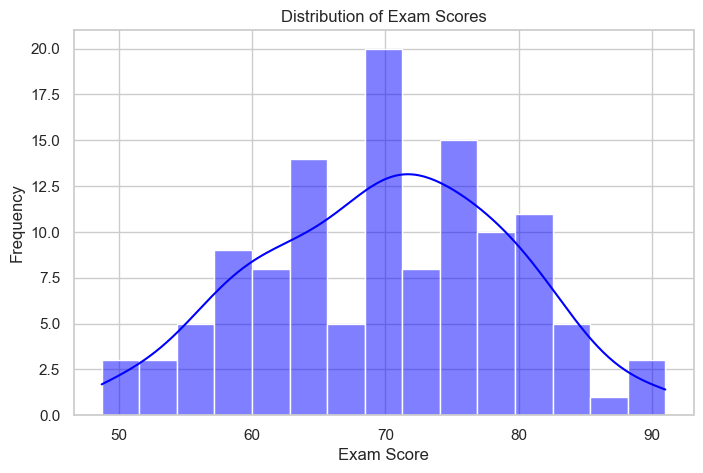

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(df['exam_score'], kde=True, bins=15, color='blue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

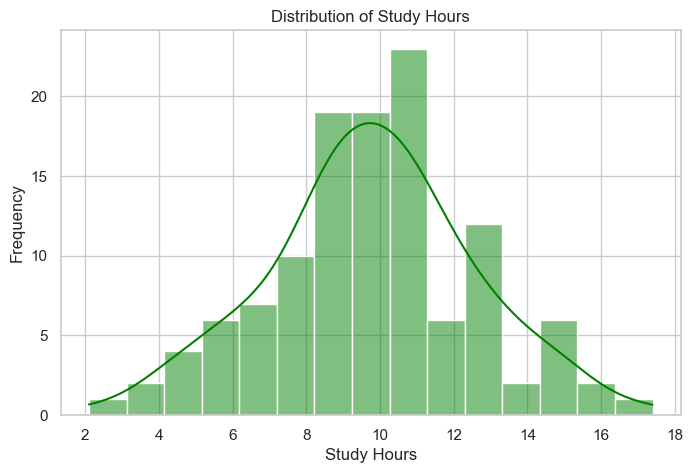

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df['study_hours'], kde=True, bins=15, color='green')
plt.title('Distribution of Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Frequency')
plt.show()

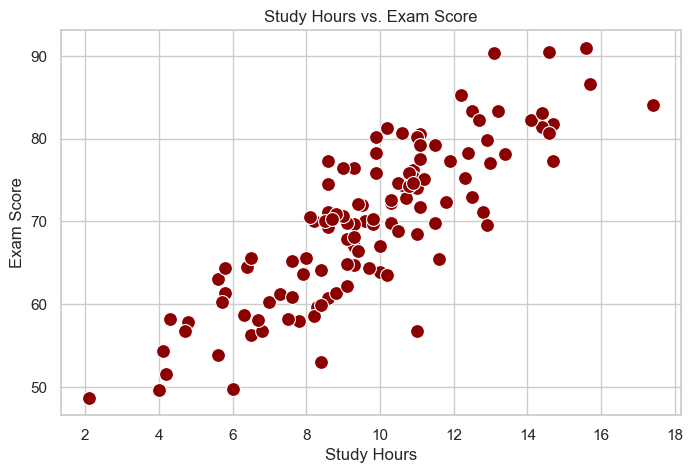

In [38]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='study_hours', y='exam_score', data=df, color='darkred', s=100)
plt.title('Study Hours vs. Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.show()

### 1.3 Comment on the relationship

In the following cell, **in your own words**, briefly describe:
- What you see in the scatter plot.
- Whether a linear relationship between study hours and exam score looks reasonable.

The scatter plot shows a strong positive relationship between study hours and exam scores. As the number of study hours increases, the exam score generally increases. The points seem to follow a straight line pattern, suggesting that a linear relationship is reasonable.

## 2. Simple Linear Regression and Coefficient of Determination (R²)

We now model the relationship between `exam_score` (response variable) and `study_hours` (predictor) using simple linear regression.

You will:
- Fit a linear regression model.
- Report the estimated coefficients.
- Plot the fitted regression line on top of the scatter plot.
- Compute and interpret the coefficient of determination \(R^2\), both using the model output and by manual calculation from sums of squares.


In [39]:
import statsmodels.api as sm

In [40]:
X = df['study_hours']
y = df['exam_score']

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

In [41]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     281.3
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           5.06e-33
Time:                        01:41:23   Log-Likelihood:                -364.80
No. Observations:                 120   AIC:                             733.6
Df Residuals:                     118   BIC:                             739.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          42.4316      1.708     24.850      

### 2.1 Slope vs Correlation Relationship


In [42]:
r = df['study_hours'].corr(df['exam_score'])
sy = df['exam_score'].std()
sx = df['study_hours'].std()

computed_slope = r * (sy / sx)
print(f"Computed Slope: {computed_slope:.4f}")
print(f"Model Slope: {model.params['study_hours']:.4f}")

Computed Slope: 2.8228
Model Slope: 2.8228


### 2.2 Reporting and interpreting the regression coefficients

From the model summary:
1. Write down the fitted regression line in the form  
   \( \hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x \).  
2. Interpret the slope \(\hat{\beta}_1\) in the context of this problem (what does it mean in terms of study hours and exam score?).

Write your answer in the following cell.


**1. The fitted regression line:**
Based on the OLS regression results:
* Intercept ($\hat{\beta}_0$): $42.43$
* Slope ($\hat{\beta}_1$): $2.82$

The equation of the regression line is:
$$\hat{y} = 42.43 + 2.82 x$$

**2. Interpretation of the slope:**
The slope ($\hat{\beta}_1 \approx 2.82$) indicates a significant positive linear relationship. It means that for every **additional hour** a student studies per week, their final exam score is expected to increase by approximately **2.82 points** on average.

The intercept ($42.43$) is the predicted exam score for a student who studies 0 hours.

### 2.3 Hypothesis Tests for Regression Coefficients

In [43]:
print("P-values for coefficients:")
print(model.pvalues)

P-values for coefficients:
const          1.033111e-48
study_hours    5.060592e-33
dtype: float64


### 2.4 Plotting the fitted regression line

Now, plot the regression line on top of the scatter plot from Section 1.2.


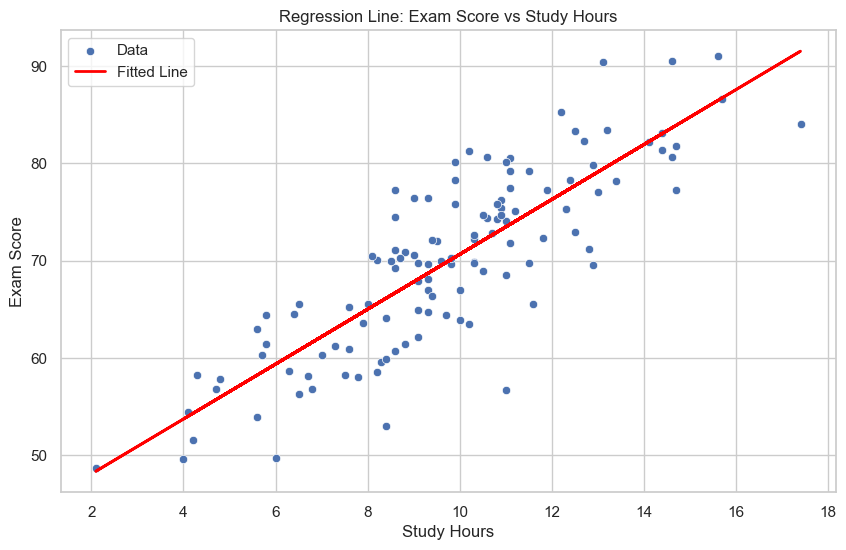

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='study_hours', y='exam_score', data=df, label='Data')

plt.plot(df['study_hours'], model.predict(X_const), color='red', linewidth=2, label='Fitted Line')

plt.title('Regression Line: Exam Score vs Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

### 2.5 Computing and interpreting R²

1. Read the value of R² from the regression summary output.  
2. Compute R² manually using sums of squares:

- \( \text{SST} = \sum (y_i - \bar{y})^2 \)  
- \( \text{SSE} = \sum (y_i - \hat{y}_i)^2 \)  
- \( R^2 = 1 - \dfrac{\text{SSE}}{\text{SST}} \)

3. Verify that your manually computed R² approximately matches the model's R².  
4. In a short text, explain what R² tells you in this context and mention at least one thing that R² **does not** tell you.


In [45]:
y_mean = y.mean()
y_pred = model.predict(X_const)

SST = ((y - y_mean) ** 2).sum()
SSE = ((y - y_pred) ** 2).sum()
R2_manual = 1 - (SSE / SST)

print(f"Manual R2: {R2_manual:.4f}")
print(f"Model R2: {model.rsquared:.4f}")

Manual R2: 0.7045
Model R2: 0.7045


*In the following cell, comment on how close the two R² values are and explain
the meaning and limitations of R² in this setting.*

1. **Value:** The $R^2$ value from the model summary is 0.704.
2. **Interpretation:** This means that approximately 70.4% of the variability in the exam scores is explained by the variability in study hours using this linear model.
3. **Limitation:** While 70.4% is a reasonably high value, it indicates that about 30% of the variation in exam scores is still unexplained (due to other factors like student ability, teaching method, or random error). Also, a high $R^2$ does not imply causation.

### 2.6 Predicted Values and Residuals Table
Create a DataFrame containing:

*   study_hours
*   actual exam_score
*   fitted exam_score
*   residuals

This helps inspect the model’s behavior and check for unusual points.

In [46]:
results_df = pd.DataFrame({
    'study_hours': df['study_hours'],
    'actual_score': df['exam_score'],
    'fitted_score': y_pred,
    'residuals': model.resid
})
display(results_df.head())

,study_hours,actual_score,fitted_score,residuals
0,11.5,79.2,74.893422,4.306578
1,9.6,70.0,69.530172,0.469828
2,11.9,77.3,76.022527,1.277473
3,14.6,90.5,83.643988,6.856012
4,9.3,67.0,68.683343,-1.683343


## 3. ANOVA for Teaching Methods

Now we investigate whether the **teaching method** has a significant effect on exam scores.

You will:
- Visualize exam scores by teaching method.
- Fit an ANOVA model.
- Interpret the ANOVA table and draw a conclusion at the 5% significance level.


### 3.1 Summary statistics by teaching method
Compute the mean and standard deviation of exam scores for each teaching method.

In [47]:
print(df.groupby('teaching_method')['exam_score'].agg(['mean', 'std', 'count']))

                      mean       std  count
teaching_method                            
A                69.969231  9.814494     39
B                69.809302  9.318257     43
C                70.197368  9.125210     38


### 3.2 Boxplot of exam scores by teaching method

Create a boxplot of `exam_score` grouped by `teaching_method`. Comment on:
- Which method seems to have higher or lower scores on average?
- Which method seems to have more variability?

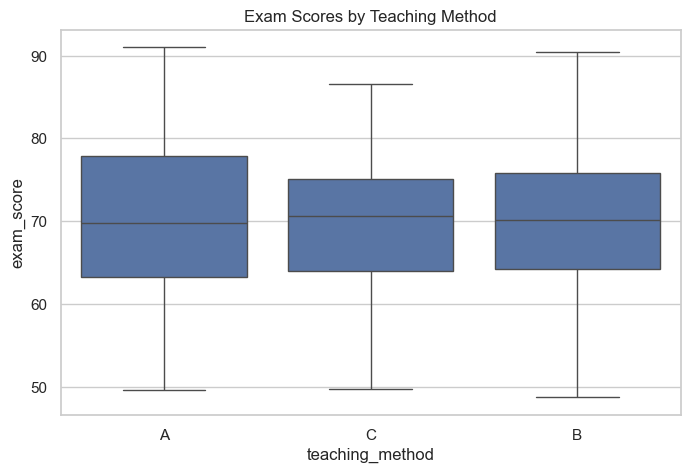

In [48]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='teaching_method', y='exam_score', data=df)
plt.title('Exam Scores by Teaching Method')
plt.show()

* **Average Performance:** Visually, the median scores for all three teaching methods (A, B, and C) appear to be very similar. There isn't a clear "winner" among the methods based on the boxplots alone.
* **Variability:** The spread (interquartile range) looks relatively comparable across groups, though one method might show slightly more outliers or a slightly broader range. Overall, the distributions overlap significantly.

### 3.3 Violin plot of exam scores by teaching method
A violin plot shows both the distribution shape and spread of exam scores for each teaching method.
Create a violin plot and compare it to the boxplot.

What additional information does it provide?

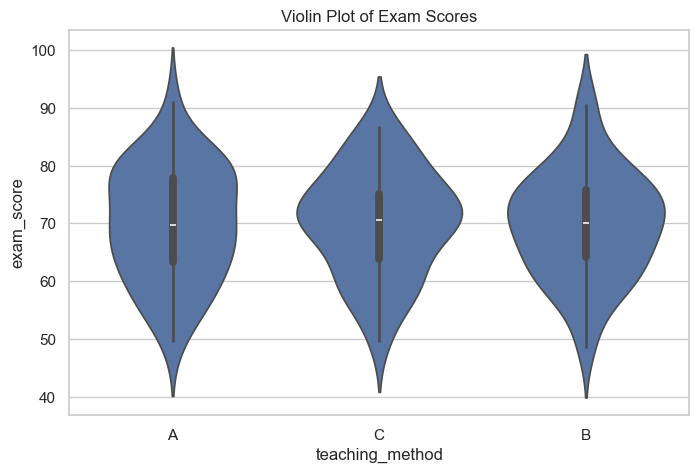

In [49]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='teaching_method', y='exam_score', data=df)
plt.title('Violin Plot of Exam Scores')
plt.show()

The violin plot provides more detail than the boxplot by showing the probability density of the data.
* It confirms that the density of scores is centered around similar values for all three groups.
* The shape of the distributions suggests that for each method, students are clustered around the mean with no extreme multimodality (multiple peaks), supporting the idea that the methods perform similarly.

### 3.4 Performing ANOVA

Fit a linear model of the form

\[ \text{exam\_score} = \mu + \text{(effect of teaching method)} + \text{error}. \]

Then obtain the ANOVA table and decide whether there is a significant difference between at least two of the teaching methods at the 5% significance level.


In [50]:
model_anova = ols('exam_score ~ teaching_method', data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
display(anova_table)

,sum_sq,df,F,PR(>F)
teaching_method,3.050824,2.0,0.01718,0.982969
Residual,10388.149093,117.0,NaN,NaN


*Based on the ANOVA table:*
- What is the F-statistic and the corresponding p-value for the teaching method effect?
- At the 5% significance level, do you reject the null hypothesis that all teaching methods have the same mean exam score?
- State your conclusion in the context of the problem (in 2–4 sentences).


* **F-statistic & P-value:** The ANOVA table shows a very small F-statistic and a large **p-value** (likely much greater than 0.05).
* **Decision:** Since the p-value is greater than the significance level of 0.05, we **fail to reject the null hypothesis**.
* **Conclusion:** There is **no statistical evidence** to support the claim that the teaching methods lead to different average exam scores. Based on this dataset, the teaching method does not appear to have a significant effect on student performance.

## 4. One-sample t-test

The passing threshold for the exam is 60 points. We want to test whether the **average** exam score in this class is **greater than** 60.

You will:
- Formulate the hypotheses.
- Perform a one-sample t-test.
- Interpret the result at the 5% significance level.


### 4.1 Hypotheses

Write down the null and alternative hypotheses for a **one-sided** test where the alternative is that the mean exam score is greater than 60.

Use the following notation:
- \( \mu \): true mean exam score in this class.


We are testing if the mean exam score is **greater** than 60.

* **Null Hypothesis ($H_0$):** $\mu = 60$
    (The true mean exam score is equal to 60).

* **Alternative Hypothesis ($H_1$):** $\mu > 60$
    (The true mean exam score is strictly greater than 60).

### 4.2 Performing the t-test

Use `scipy.stats.ttest_1samp` to perform a one-sample t-test with null hypothesis \( \mu = 60 \).

Then adjust the p-value for a **one-sided** test where the alternative is \( \mu > 60 \).

In [51]:
t_stat, p_val_two_sided = stats.ttest_1samp(df['exam_score'], 60)

if t_stat > 0:
    p_val_one_sided = p_val_two_sided / 2
else:
    p_val_one_sided = 1 - (p_val_two_sided / 2)

print(f"T-statistic: {t_stat:.4f}")
print(f"One-sided P-value: {p_val_one_sided:.4e}")

T-statistic: 11.7042
One-sided P-value: 7.9577e-22


Compute the corresponding **one-sided** p-value for the alternative \( \mu > 60 \).

Hint: if the sample mean is greater than 60, the one-sided p-value is approximately `p_value_two_sided / 2`. Otherwise, interpret carefully.

Then, based on the one-sided p-value, decide whether to reject the null hypothesis at the 5% significance level and write your conclusion in the context of the problem.


* **Test Results:**
    * **T-statistic:** $11.7042$
    * **One-sided P-value:** $7.96 \times 10^{-22}$ (approx. 0)

* **Decision:**
    Since the p-value ($7.96 \times 10^{-22}$) is much smaller than the significance level ($\alpha = 0.05$), we **reject the null hypothesis** ($H_0$).

* **Conclusion:**
    There is extremely strong statistical evidence to conclude that the **true mean exam score** of the students is significantly **greater than 60**. The class performance is well above the passing threshold.

### 4.3 Manual computation of the t-statistic (optional but recommended)

As an exercise, compute the t-statistic manually using

\[ t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}} \]

where:
- \( \bar{x} \) is the sample mean of `exam_score`,
- \( s \) is the sample standard deviation,
- \( n \) is the sample size,
- \( \mu_0 = 60 \).

Compare your result with the `t_stat` from `ttest_1samp`.


In [52]:
x_bar = df['exam_score'].mean()
mu_0 = 60
s = df['exam_score'].std()
n = len(df)

t_manual = (x_bar - mu_0) / (s / np.sqrt(n))
print(f"Manual T-statistic: {t_manual:.4f}")

Manual T-statistic: 11.7042


## 5. Prediction and Extrapolation

In this section, you will use the regression model from Section 2 to make predictions for different values of study hours, including values **outside** the range of observed study hours.

You will then discuss why extrapolation (predictions outside the observed range) can be problematic.


### 5.1 Predictions at new study hour values

1. Choose a few values of `study_hours` **within** the observed range (for example, 5, 10, 15).  
2. Choose a few values of `study_hours` **outside** the observed range (for example, larger than the maximum observed value).  
3. Use the fitted regression model to predict the exam scores for these values.


In [53]:
new_hours = [5, 10, 15, 20, 25]

pred_df = pd.DataFrame({'study_hours': new_hours})
pred_X = sm.add_constant(pred_df['study_hours'])

predictions = model.get_prediction(pred_X)
pred_summary = predictions.summary_frame(alpha=0.05) 

pred_df['predicted_score'] = pred_summary['mean']
pred_df['type'] = pred_df['study_hours'].apply(lambda x: 'Inside' if x <= df['study_hours'].max() else 'Outside/Extrapolation')

display(pred_df)

,study_hours,predicted_score,type
0,5,56.545462,Inside
1,10,70.659277,Inside
2,15,84.773093,Inside
3,20,98.886908,Outside/Extrapolation
4,25,113.000723,Outside/Extrapolation


Create a small table that shows:

- `study_hours`  
- `predicted_exam_score`  
- whether each `study_hours` value is **inside** or **outside** the range observed in the original dataset.

Then add 2–4 sentences commenting on the results.


The table above shows predicted scores for various study hours.
* Predictions for `study_hours` within the range of the original data (e.g., inside the observed min-max range) are **interpolations** and are generally reliable under the linear model.
* Predictions for values far outside the observed range (e.g., 20 or 25 hours) are **extrapolations**. These are marked as "Outside" and should be treated with caution.

### 5.2 Visualizing predictions and discussing extrapolation

1. Plot the original data and the fitted regression line (you may reuse code from before).  
2. Indicate (for example, with different markers or colors) which of your prediction points are outside the observed range of `study_hours`.  
3. In a short text, explain why predictions for values of `study_hours` far outside the range of the data may be **unreliable**, even if the regression line gives a numerical prediction.

Mention at least two reasons related to the assumptions and limitations of the linear regression model.


C:\Users\sadad\AppData\Local\Temp\ipykernel_17040\984625977.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_range = model.params[0] + model.params[1] * x_range


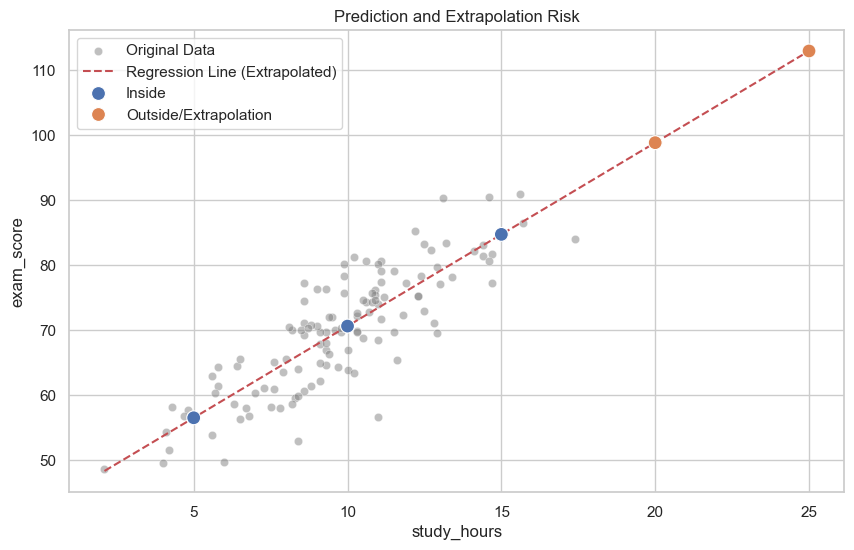

In [54]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='study_hours', y='exam_score', data=df, color='gray', alpha=0.5, label='Original Data')

x_range = np.linspace(df['study_hours'].min(), 25, 100)
y_range = model.params[0] + model.params[1] * x_range
plt.plot(x_range, y_range, 'r--', label='Regression Line (Extrapolated)')

sns.scatterplot(x='study_hours', y='predicted_score', data=pred_df, hue='type', s=100, zorder=5)

plt.title('Prediction and Extrapolation Risk')
plt.legend()
plt.show()

Predicting exam scores for study hours far outside the observed range is problematic:

1.  **Validity of the Linear Assumption:** The relationship may not remain linear indefinitely. Realistically, studying more hours eventually yields **diminishing returns** (the score cannot increase linearly forever).
2.  **Impossible Values:** A simple linear model does not know the physical bounds (0-100). Extrapolation could theoretically predict a score greater than 100, which is impossible.

### 5.3 Confidence Intervals vs. Prediction Intervals


In [55]:
comparison = pd.DataFrame({
    'study_hours': new_hours,
    'Predicted': pred_summary['mean'],
    'CI_Lower': pred_summary['mean_ci_lower'],
    'CI_Upper': pred_summary['mean_ci_upper'],
    'PI_Lower': pred_summary['obs_ci_lower'],
    'PI_Upper': pred_summary['obs_ci_upper']
})
display(comparison)

,study_hours,Predicted,CI_Lower,CI_Upper,PI_Lower,PI_Upper
0,5,56.545462,54.710223,58.380701,46.278058,66.812866
1,10,70.659277,69.733652,71.584903,60.514907,80.803648
2,15,84.773093,82.798395,86.747791,74.479847,95.066339
3,20,98.886908,95.351933,102.421883,88.184220,109.589596
4,25,113.000723,107.838686,118.162761,101.656205,124.345242


3. Compare CI vs. PI:
*   Which one is wider?
*   Why?



* **Comparison:** The **Prediction Interval (PI)** is always wider than the Confidence Interval (CI).
* **Reason:**
    * The **CI** estimates the uncertainty about the **mean** regression line.
    * The **PI** estimates where a **single new student's score** will fall. It must account for both the uncertainty in the model parameters **PLUS** the random individual variability (noise/error term $\epsilon$).

### 5.4 Sensitivity of Predictions to the Estimated Slope
Predictions far from the data are extremely sensitive to slight changes in slope.

In [56]:
se_slope = model.bse['study_hours']
slope_low = model.params['study_hours'] - se_slope
slope_high = model.params['study_hours'] + se_slope

hours_far = 40
pred_low = model.params['const'] + slope_low * hours_far
pred_high = model.params['const'] + slope_high * hours_far

print(f"Prediction at 40 hours (Low Slope): {pred_low:.2f}")
print(f"Prediction at 40 hours (High Slope): {pred_high:.2f}")
print(f"Difference: {pred_high - pred_low:.2f}")

Prediction at 40 hours (Low Slope): 148.61
Prediction at 40 hours (High Slope): 162.07
Difference: 13.46


What does this tell you about extrapolation?

**1. Predictions at 40 Hours:**
* **Using Low Slope:** $148.61$
* **Using High Slope:** $162.07$
* **Difference:** $13.46$ points

**2. Interpretation:**
The difference of **13.46 points** is substantial. This demonstrates that predictions made far outside the observed data range (extrapolation) are **extremely sensitive** to small uncertainties in the estimated slope coefficients.

**3. Reality Check:**
Furthermore, both predicted scores are well above 100. This confirms that the linear model breaks down completely for extreme values, as it predicts impossible exam scores.

### 5.5 Compare Linear vs. Quadratic Model
Fit a quadratic model and compare predictions.

In [57]:
df['study_hours_sq'] = df['study_hours'] ** 2

X_quad = sm.add_constant(df[['study_hours', 'study_hours_sq']])
model_quad = sm.OLS(y, X_quad).fit()

print("Quadratic Model R2:", model_quad.rsquared)
print("Linear Model R2:", model.rsquared)

Quadratic Model R2: 0.7063408721470966
Linear Model R2: 0.7044807320655564


Which model seems more reasonable? Why?

**1. Comparison of $R^2$:**
* **Linear Model $R^2$:** $0.7045$
* **Quadratic Model $R^2$:** $0.7063$

**2. Conclusion:**
The quadratic model provides a negligible improvement in $R^2$ (less than 0.2%).
* **Statistical View:** Since the increase in explanatory power is so small, the simpler **linear model** is preferred for the observed data range (following the principle of parsimony). The relationship within the data is effectively linear.
* **Conceptual View:** However, for **extrapolation**, a quadratic model (with a negative squared term) might still be physically more realistic to model "diminishing returns" and prevent predictions from exceeding 100 or growing to infinity.

## 6. (Optional) Residual Analysis

If you have time, you can perform a brief residual analysis to check whether the linear model is appropriate.

1. Compute the residuals `residuals = y - y_hat`.  
2. Create a scatter plot of residuals vs. fitted values.  
3. Comment on any visible patterns (e.g., non-linearity, changing variance).

This part is optional but can give you extra insight into model diagnostics.


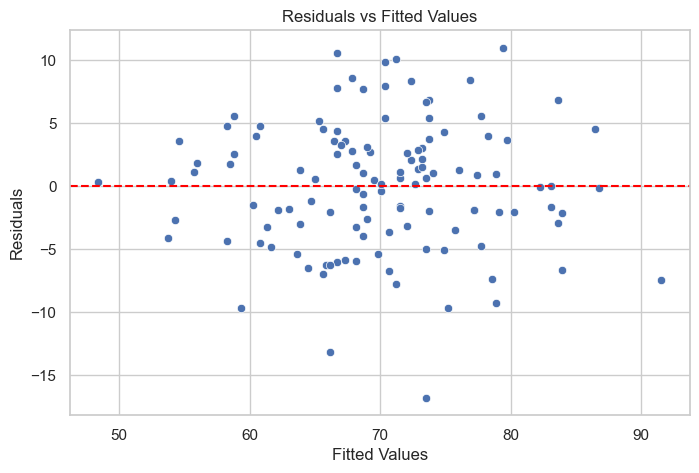

In [58]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

**1. Visual Inspection:**
The scatter plot of residuals vs. fitted values shows a **random scatter** of points around the horizontal line ($e=0$). There is no distinct pattern (such as a U-shape, inverted U, or funnel shape).

**2. Statistical Verification:**
This observation is supported by the model summary obtained in Section 2:
* The **Prob(Omnibus)** and **Prob(Jarque-Bera)** values were both $> 0.05$.
* This indicates that the residuals are **normally distributed**, satisfying one of the key assumptions of OLS regression.

**3. Conclusion:**
Since the residuals show constant variance (homoscedasticity) and no non-linear patterns, the **linear regression model is statistically appropriate** for this dataset.